In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('../data/cleaned/cleaned_data.csv')

In [4]:
df.head(10)

,Brand,Date,Campaign_Type,Target_Audience,Channel_Used,Language,Customer_Segment,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score,Total_Cost
0,Nykaa,2025-04-29,Social Media,College Students,"Whatsapp, Youtube",Hindi,College Students,21.0,57804,6156,3616,2355,1867515,209,2.79,20.98,492195
1,Nykaa,2025-04-06,Paid Ads,Tier 2 City Customers,Youtube,Hindi,College Students,18.0,91801,3321,1971,1357,1046247,180,3.28,7.24,244260
2,Nykaa,2025-01-14,Influencer,Youth,"Whatsapp, Google, Youtube",English,College Students,23.0,15536,2182,952,755,197055,90,1.90,25.03,67950
3,Nykaa,2025-06-04,Email,Working Women,"Youtube, Facebook, Instagram",Hindi,Youth,18.0,88114,8413,2231,947,376906,249,0.60,13.15,235803
4,Nykaa,2024-12-29,Paid Ads,College Students,"Facebook, Instagram",Hindi,Tier 2 City Customers,10.0,96871,3743,2060,1258,518296,228,0.81,7.29,286824
5,Nykaa,2024-09-23,Influencer,Youth,"Email, Instagram",Tamil,Premium Shoppers,26.0,83919,7497,2061,1555,877020,137,3.12,13.24,213035
6,Nykaa,2024-09-01,Paid Ads,College Students,"Youtube, Google, Whatsapp",Tamil,Youth,21.0,82267,6952,1873,1386,633402,210,1.18,14.59,291060
7,Nykaa,2025-05-31,Social Media,Working Women,"Youtube, Email",Hindi,Tier 2 City Customers,6.0,32482,2665,1488,925,326525,147,1.40,15.63,135975
8,Nykaa,2025-03-24,Influencer,Premium Shoppers,"Facebook, Whatsapp, Email",Hindi,Tier 2 City Customers,27.0,73813,8680,5031,2551,1058665,87,3.77,22.03,221937
9,Nykaa,2025-04-29,Influencer,College Students,Email,Hindi,Youth,11.0,88895,6284,1600,858,603174,269,1.61,9.83,230802


In [5]:
df.tail(10)

,Brand,Date,Campaign_Type,Target_Audience,Channel_Used,Language,Customer_Segment,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score,Total_Cost
166277,Tira,2025-03-01,Social Media,College Students,"Facebook, Instagram, Youtube",English,College Students,7.0,78207,3086,883,620,199020,362,-0.11,5.87,224440
166278,Tira,2024-09-25,Social Media,Premium Shoppers,Instagram,Hindi,Premium Shoppers,14.0,38933,2683,1307,931,641459,298,1.31,10.18,277438
166279,Tira,2025-03-06,Email,College Students,"Facebook, Google",Bengali,College Students,21.0,64396,6408,1943,1450,687300,181,1.62,15.22,262450
166280,Tira,2025-05-19,Influencer,Premium Shoppers,"Whatsapp, Youtube, Google",Hindi,Working Women,15.0,25929,1388,808,567,408240,258,1.79,10.66,146286
166281,Tira,2024-09-30,Paid Ads,Premium Shoppers,Facebook,English,Tier 2 City Customers,26.0,33252,2871,950,521,258937,421,0.18,12.96,219341
166282,Tira,2024-11-12,Email,Tier 2 City Customers,"Instagram, Youtube, Email",Bengali,Youth,11.0,55113,3799,1511,1099,454986,213,0.94,10.70,234087
166283,Tira,2024-08-25,Seo,Working Women,"Google, Instagram",English,Working Women,20.0,54886,1578,634,348,136514,436,-0.10,4.66,151728
166284,Tira,2025-04-15,Email,Working Women,"Facebook, Instagram",English,Premium Shoppers,13.0,97954,11480,4567,2144,445952,78,1.67,18.57,167232
166285,Tira,2024-07-21,Influencer,Premium Shoppers,"Google, Email",English,Working Women,22.0,11669,986,122,44,26884,209,1.92,5.35,9196
166286,Tira,2025-05-02,Paid Ads,Working Women,Instagram,English,Premium Shoppers,17.0,50497,1604,542,363,281688,151,4.14,4.97,54813


In [6]:
brand_summary = df.groupby('Brand')[['Revenue','ROI','Conversions','Acquisition_Cost']].mean().round(2)
print(brand_summary)

           Revenue   ROI  Conversions  Acquisition_Cost
Brand                                                  
Nykaa    514209.95  2.68      1030.17            369.10
Purplle  512516.76  2.64      1026.37            369.79
Tira     510966.65  2.64      1023.68            366.99


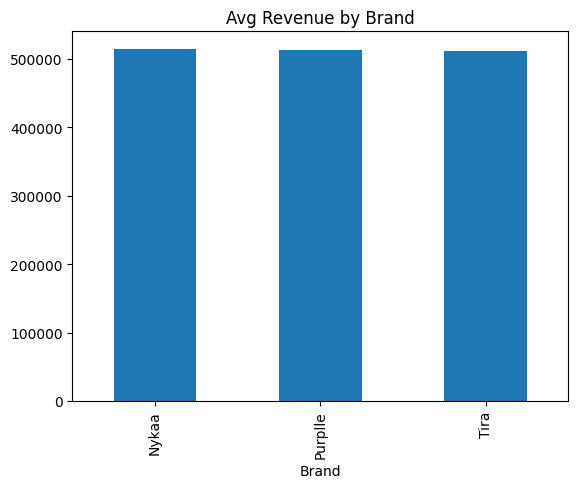

In [7]:
brand_summary['Revenue'].plot(kind='bar', title='Avg Revenue by Brand')
plt.show()

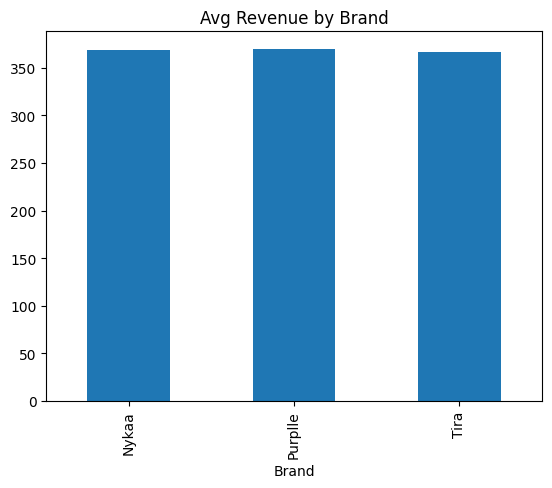

In [10]:
brand_summary['Acquisition_Cost'].plot(kind='bar', title='Avg Revenue by Brand')
plt.show()

In [11]:
channel_df = df.assign(Channel_Used=df['Channel_Used'].str.split(',')).explode('Channel_Used')
channel_df['Channel_Used'] = channel_df['Channel_Used'].str.strip()

channel_summary = channel_df.groupby('Channel_Used')[['Revenue','ROI','Conversions']].mean().round(2).sort_values('ROI', ascending=False)
print(channel_summary)

                Revenue   ROI  Conversions
Channel_Used                              
Email         515161.44  2.69      1031.59
Instagram     515674.20  2.69      1031.01
Google        510361.33  2.65      1017.89
Facebook      511621.08  2.64      1026.85
Whatsapp      512675.04  2.64      1028.29
Youtube       510573.15  2.63      1023.48


In [12]:
top10 = df.nlargest(10, 'Revenue')[['Brand','Campaign_Type','Channel_Used','Revenue','ROI']]
bottom10 = df.nsmallest(10, 'Revenue')[['Brand','Campaign_Type','Channel_Used','Revenue','ROI']]

In [13]:
top10

,Brand,Campaign_Type,Channel_Used,Revenue,ROI
11980,Nykaa,Paid Ads,"Email, Youtube, Facebook",4579910,2.28
152077,Tira,Paid Ads,Youtube,4517478,17.14
43061,Nykaa,Seo,Youtube,4412709,42.72
76654,Purplle,Paid Ads,"Whatsapp, Youtube",4345920,20.82
37302,Nykaa,Influencer,Instagram,4326120,13.64
143523,Tira,Seo,"Facebook, Whatsapp",4277700,14.64
162535,Tira,Influencer,"Facebook, Email",4231273,2.81
137598,Tira,Email,"Youtube, Google",4207876,19.77
90652,Purplle,Influencer,Instagram,4195620,38.00
159131,Tira,Social Media,Email,4187248,17.22


In [14]:
bottom10

,Brand,Campaign_Type,Channel_Used,Revenue,ROI
138839,Tira,Email,Email,3895,-0.99
72307,Purplle,Seo,"Email, Whatsapp, Youtube",6061,-0.95
130554,Tira,Influencer,"Instagram, Whatsapp, Email",6072,-0.98
23356,Nykaa,Paid Ads,"Facebook, Youtube",6183,-0.97
132129,Tira,Paid Ads,Instagram,6240,-0.95
70355,Purplle,Email,"Youtube, Facebook, Email",6902,-0.88
165934,Tira,Email,Instagram,6987,-0.97
125094,Tira,Social Media,"Whatsapp, Facebook, Youtube",7245,-0.90
79145,Purplle,Influencer,"Youtube, Email, Whatsapp",7350,-0.97
85042,Purplle,Email,"Facebook, Google",7455,-0.95


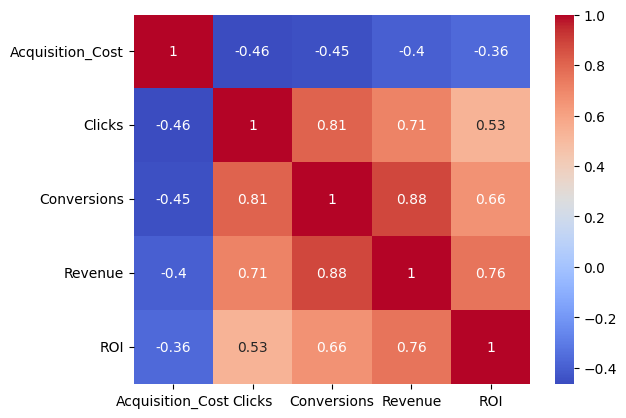

In [15]:
sns.heatmap(df[['Acquisition_Cost','Clicks','Conversions','Revenue','ROI']].corr(), annot=True, cmap='coolwarm')
plt.show()

In [21]:
df['Date'] = pd.to_datetime(df['Date'])

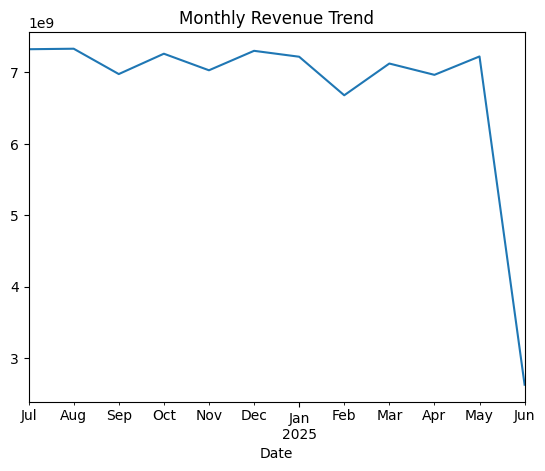

In [22]:
trend = df.dropna(subset=['Date']).groupby(df['Date'].dt.to_period('M'))['Revenue'].sum()
trend.plot(kind='line', title='Monthly Revenue Trend')
plt.show()

In [23]:
df.groupby('Campaign_Type')[['Revenue','ROI','Conversions']].mean().round(2).sort_values('ROI', ascending=False)

,Revenue,ROI,Conversions
Campaign_Type,,,
Paid Ads,517054.91,2.68,1031.06
Email,512600.47,2.66,1025.91
Social Media,512691.93,2.66,1030.80
Seo,510003.41,2.65,1020.81
Influencer,510488.44,2.62,1025.15


In [24]:
mismatch = (df['Target_Audience'] != df['Customer_Segment']).mean() * 100
print(f"{mismatch:.1f}% of campaigns had actual segment ≠ intended target")

80.1% of campaigns had actual segment ≠ intended target


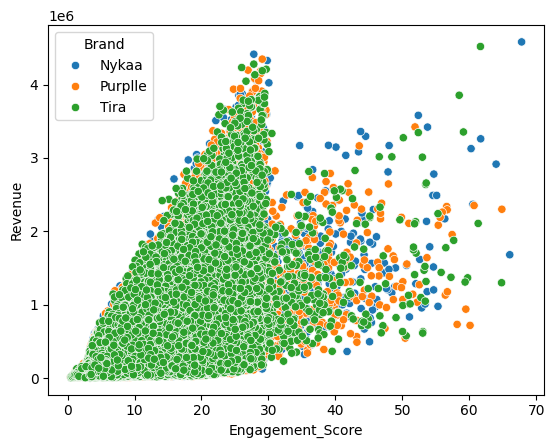

In [25]:
sns.scatterplot(data=df, x='Engagement_Score', y='Revenue', hue='Brand')
plt.show()

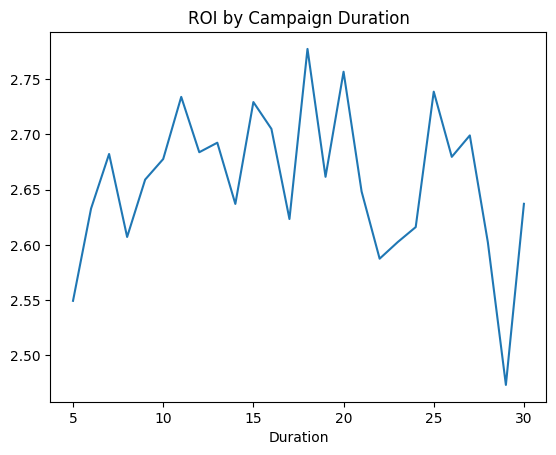

In [26]:
df.groupby('Duration')['ROI'].mean().plot(kind='line', title='ROI by Campaign Duration')
plt.show()

In [27]:
df.groupby('Language')[['Revenue','ROI']].mean().round(2).sort_values('ROI', ascending=False)

,Revenue,ROI
Language,,
Hindi,513882.76,2.69
Tamil,513897.36,2.67
English,512783.43,2.65
Bengali,509684.14,2.62


EDA was conducted across brand, channel, campaign type, temporal, and engagement dimensions. Revenue is primarily driven by Conversions and Leads, with weaker influence from top-funnel metrics like Impressions.
Acquisition_Cost shows a mild negative relationship with Revenue, suggesting cost efficiency doesn't compromise performance. 
Brand and channel-level analysis revealed clear performance gaps, useful for budget reallocation recommendations. 
A notable mismatch between intended Target_Audience and actual Customer_Segment points to a targeting-precision opportunity.
These insights directly informed feature selection for the modeling stage — prioritizing Conversions, Leads, Engagement_Score, and Total_Cost as primary predictors.